# 01 Exploratory Data Analysis: UCI Heart Disease

This notebook completes the first exploratory analysis layer for the clinical risk modeling portfolio project. It documents and explores the local UCI processed Cleveland Heart Disease file without training machine learning models.

## Project Context

Project line: Biomedical Data Science for Personalized Medicine.

Current phase: data documentation and exploratory data analysis only. This notebook is educational and does not present a diagnostic medical tool or clinical decision support system.

## Dataset Citation

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X

Dataset page: https://archive.ics.uci.edu/dataset/45/heart+disease

License: CC BY 4.0, according to the UCI dataset page.

## Ethical Note

The dataset is public, but it originates from clinical data. Interpretations should remain cautious, descriptive, and limited to this dataset. Do not use this notebook for medical diagnosis, treatment decisions, or causal claims.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_processing import (  # noqa: E402
    HEART_DISEASE_COLUMNS,
    binarize_heart_disease_target,
    clean_missing_values,
    load_heart_disease_data,
)

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "processed.cleveland.data"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)

## Load Data

Expected raw file path: `data/raw/processed.cleveland.data`. The file is intentionally not tracked in Git.

In [2]:
def load_dataset_or_explain(path: Path) -> pd.DataFrame | None:
    """Load the local UCI file or print manual download instructions."""
    if not path.exists():
        print("Raw data file not found.")
        print("Download the UCI Heart Disease dataset from:")
        print("https://archive.ics.uci.edu/dataset/45/heart+disease")
        print("Place the processed Cleveland file at:")
        print(path.relative_to(PROJECT_ROOT))
        return None

    data = clean_missing_values(load_heart_disease_data(path))
    for column in HEART_DISEASE_COLUMNS:
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data["target_binary"] = binarize_heart_disease_target(data, "target")["target"]
    return data


df = load_dataset_or_explain(RAW_DATA_PATH)
print(HEART_DISEASE_COLUMNS)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


## Basic DataFrame Inspection

In [3]:
if df is not None:
    print(f"Dataset shape: {df.shape[0]} rows x {len(HEART_DISEASE_COLUMNS)} original columns")
    print(f"Analysis columns including target_binary: {df.shape[1]}")
    print(df.head().to_string(index=False))

Dataset shape: 303 rows x 14 original columns
Analysis columns including target_binary: 15
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target  target_binary
63.0  1.0 1.0     145.0 233.0  1.0      2.0    150.0    0.0      2.3    3.0 0.0   6.0       0              0
67.0  1.0 4.0     160.0 286.0  0.0      2.0    108.0    1.0      1.5    2.0 3.0   3.0       2              1
67.0  1.0 4.0     120.0 229.0  0.0      2.0    129.0    1.0      2.6    2.0 2.0   7.0       1              1
37.0  1.0 3.0     130.0 250.0  0.0      0.0    187.0    0.0      3.5    3.0 0.0   3.0       0              0
41.0  0.0 2.0     130.0 204.0  0.0      2.0    172.0    0.0      1.4    1.0 0.0   3.0       0              0


In [4]:
if df is not None:
    print(df.dtypes.to_frame("dtype").to_string())

                 dtype
age            float64
sex            float64
cp             float64
trestbps       float64
chol           float64
fbs            float64
restecg        float64
thalach        float64
exang          float64
oldpeak        float64
slope          float64
ca             float64
thal           float64
target           int64
target_binary    int64


## Missing Values and Duplicates

In [5]:
if df is not None:
    missing = (
        df[HEART_DISEASE_COLUMNS]
        .isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_percent=lambda table: table["missing_count"] / len(df) * 100)
        .sort_values("missing_count", ascending=False)
    )
    duplicate_count = int(df[HEART_DISEASE_COLUMNS].duplicated().sum())
    print(missing.to_string())
    print(f"Duplicate rows: {duplicate_count}")

          missing_count  missing_percent
ca                    4         1.320132
thal                  2         0.660066
cp                    0         0.000000
trestbps              0         0.000000
age                   0         0.000000
sex                   0         0.000000
fbs                   0         0.000000
chol                  0         0.000000
restecg               0         0.000000
thalach               0         0.000000
oldpeak               0         0.000000
exang                 0         0.000000
slope                 0         0.000000
target                0         0.000000
Duplicate rows: 0


## Target Distribution

The original target coding uses `0`, `1`, `2`, `3`, and `4`. For exploratory summaries, `target_binary` maps `0` to `0` and values greater than `0` to `1`. This is a dataset-label transformation, not a medical diagnosis.

In [6]:
if df is not None:
    target_counts = df["target"].value_counts(dropna=False).sort_index()
    binary_counts = df["target_binary"].value_counts(dropna=False).sort_index()

    print("Original target distribution")
    print(target_counts.rename("count").to_frame().to_string())
    print("\nBinary target distribution")
    print(binary_counts.rename("count").to_frame().to_string())

Original target distribution
        count
target       
0         164
1          55
2          36
3          35
4          13

Binary target distribution
               count
target_binary       
0                164
1                139


## Numeric and Categorical Summaries

In [7]:
numeric_columns = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "target",
    "target_binary",
]

if df is not None:
    print(df[numeric_columns].describe().T.round(2).to_string())
    for column in categorical_columns:
        print(f"\n{column}")
        counts = df[column].value_counts(dropna=False).sort_index()
        print(counts.rename("count").to_frame().to_string())

          count    mean    std    min    25%    50%    75%    max
age       303.0   54.44   9.04   29.0   48.0   56.0   61.0   77.0
trestbps  303.0  131.69  17.60   94.0  120.0  130.0  140.0  200.0
chol      303.0  246.69  51.78  126.0  211.0  241.0  275.0  564.0
thalach   303.0  149.61  22.88   71.0  133.5  153.0  166.0  202.0
oldpeak   303.0    1.04   1.16    0.0    0.0    0.8    1.6    6.2

sex
     count
sex       
0.0     97
1.0    206

cp
     count
cp        
1.0     23
2.0     50
3.0     86
4.0    144

fbs
     count
fbs       
0.0    258
1.0     45

restecg
         count
restecg       
0.0        151
1.0          4
2.0        148

exang
       count
exang       
0.0      204
1.0       99

slope
       count
slope       
1.0      142
2.0      140
3.0       21

ca
     count
ca        
0.0    176
1.0     65
2.0     38
3.0     20
NaN      4

thal
      count
thal       
3.0     166
6.0      18
7.0     117
NaN       2

target
        count
target       
0         164
1          5

## Basic Visualizations

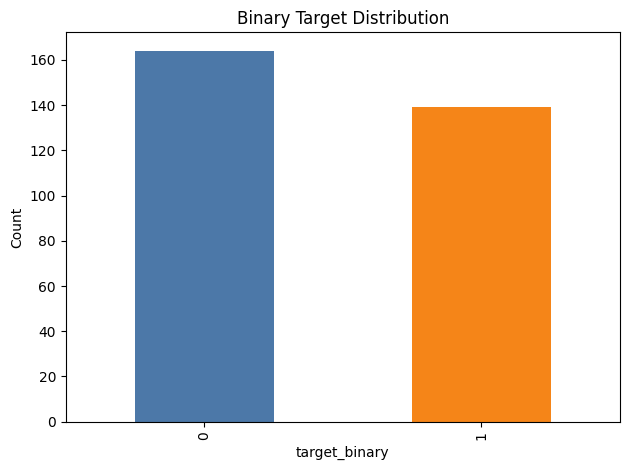

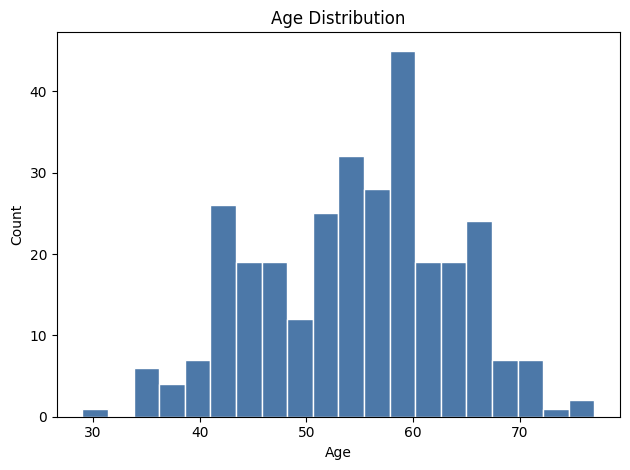

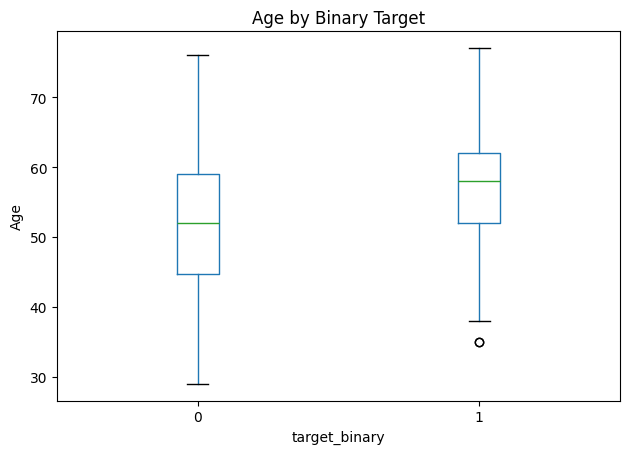

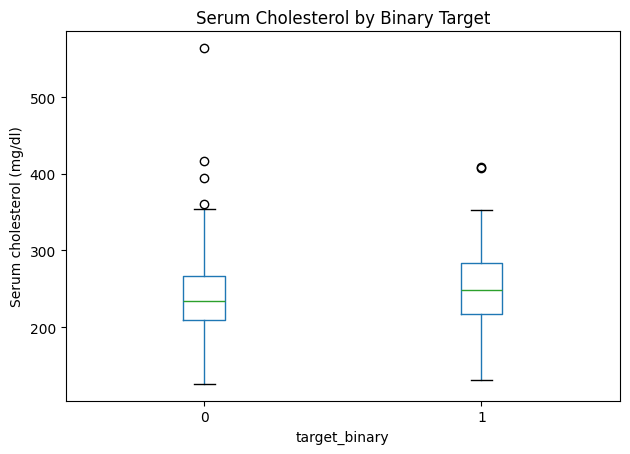

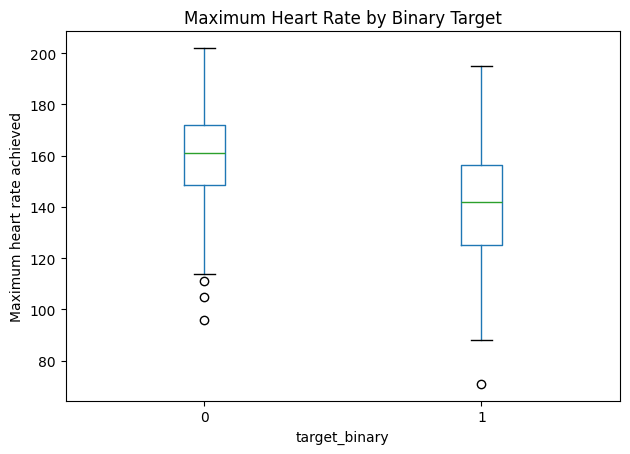

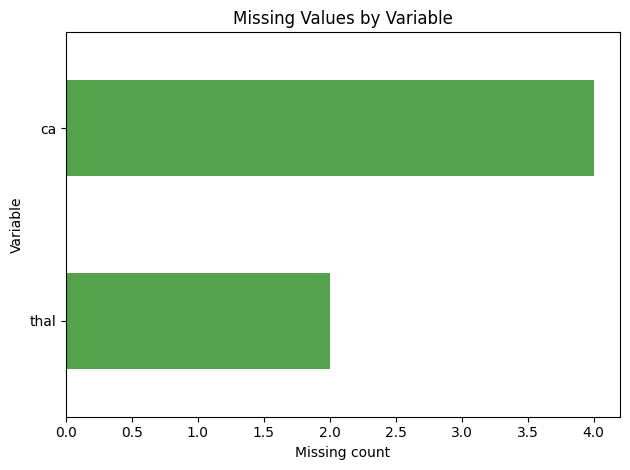

In [8]:
def save_current_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()


if df is not None:
    ax = df["target_binary"].value_counts().sort_index().plot(kind="bar", color=["#4c78a8", "#f58518"])
    ax.set_title("Binary Target Distribution")
    ax.set_xlabel("target_binary")
    ax.set_ylabel("Count")
    save_current_figure("target_distribution.png")

    ax = df["age"].plot(kind="hist", bins=20, color="#4c78a8", edgecolor="white")
    ax.set_title("Age Distribution")
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")
    save_current_figure("age_distribution.png")

    df.boxplot(column="age", by="target_binary", grid=False)
    plt.title("Age by Binary Target")
    plt.suptitle("")
    plt.xlabel("target_binary")
    plt.ylabel("Age")
    save_current_figure("age_by_target_binary.png")

    df.boxplot(column="chol", by="target_binary", grid=False)
    plt.title("Serum Cholesterol by Binary Target")
    plt.suptitle("")
    plt.xlabel("target_binary")
    plt.ylabel("Serum cholesterol (mg/dl)")
    save_current_figure("cholesterol_by_target_binary.png")

    df.boxplot(column="thalach", by="target_binary", grid=False)
    plt.title("Maximum Heart Rate by Binary Target")
    plt.suptitle("")
    plt.xlabel("target_binary")
    plt.ylabel("Maximum heart rate achieved")
    save_current_figure("max_heart_rate_by_target_binary.png")

    missing_nonzero = missing[missing["missing_count"] > 0]
    if missing_nonzero.empty:
        missing_nonzero = missing.head(1)
    ax = missing_nonzero["missing_count"].sort_values().plot(kind="barh", color="#54a24b")
    ax.set_title("Missing Values by Variable")
    ax.set_xlabel("Missing count")
    ax.set_ylabel("Variable")
    save_current_figure("missing_values.png")

## Cautious Biomedical Interpretation

The EDA shows a compact historical dataset with 303 records and 14 original variables. Missing values are limited to `ca` and `thal` in this local file, and no duplicate rows were observed. The binary target is reasonably represented across the two exploratory groups. Some descriptive differences are visible in variables such as age and maximum heart rate achieved, but these are dataset-level observations only. They should not be interpreted as causal effects or as evidence that this notebook can diagnose disease.

## Limitations

- The dataset is historical and may not reflect current clinical practice.
- The processed Cleveland file is a reduced 14-variable version of the original database.
- Several predictors are encoded categories that require careful documentation before modeling.
- Missing values in `ca` and `thal` require explicit preprocessing decisions.
- This analysis is educational and not clinically deployable.

## Next Steps

1. Review the saved figures and missingness summary.
2. Decide transparent preprocessing rules for missing and categorical values.
3. Define train/test splitting and leakage checks before any modeling.
4. Add simple baseline modeling only in a later phase.